# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv('/content/House_Rent_Dataset.csv', sep=None, engine='python')
df.shape

(4746, 12)

In [61]:
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [11]:
df.dtypes

,0
Posted On,object
BHK,int64
Rent,int64
Size,int64
Floor,object
Area Type,object
Area Locality,object
City,object
Furnishing Status,object
Tenant Preferred,object


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [19]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_percent

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


У датасеті немає пропущених значень.

In [20]:
stat = df.describe()
stat.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


В датасеті 4 стовпці з числовими змінними.

In [22]:
df_clean = df[df['Rent'].notna()].copy()

fig = px.histogram(
    df_clean,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (Орендна плата)',
    labels={'Rent': 'Орендна плата', 'count': 'Кількість обʼєктів оренди'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

Робота з викидами

In [23]:
Q1 = df_clean['Rent'].quantile(0.25)
Q3 = df_clean['Rent'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean['Rent'] < lower) |
    (df_clean['Rent'] > upper)
]

print(f"Кількість викидів: {len(outliers)}")

Кількість викидів: 520


In [92]:
df_clean2 = df_clean[
    (df_clean['Rent'] >= lower) &
    (df_clean['Rent'] <= upper)
]

In [26]:
fig = px.histogram(
    df_clean2,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (Орендна плата)',
    labels={'Rent': 'Орендна плата', 'count': 'Кількість обʼєктів оренди'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

Видалено 520 рядків з даними, які є викидами. Тепер розподіл змінної Rent виглядає більш наочно.

**Аналіз категоріальних змінних**. Виведіть кількість унікальних значень для кожної з категоріальних колонок.

In [53]:
cat_cols = df_clean2.select_dtypes(['object']).columns
df_clean2[cat_cols].nunique()

,0
Posted On,80
Floor,340
Area Type,3
Area Locality,1997
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


Отже, у нас найбільше унікальних значень для району, значно менше для поверху та дати розміщення оголошення. Інші категорії мають по 3 значення, а місто - лише 6.


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [54]:
metrics_df = df_clean2[['Rent', 'BHK',	'Size',	'Bathroom']].dropna()

correlation_matrix = metrics_df.corr()

fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими метриками',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

З числових даних на показник Rent вплив відносно невеликий (від 0.4 до 0.5) всіх трьох показників, найбільше впливає Кількість ванних кімнат. Серед самих показників (BHK, Size, Bathroom) присутня суттєво більша кореляція (0.7 - 0.75).

In [55]:
correlation_matrix['Rent'].sort_values()

,Rent
Size,0.393605
BHK,0.401268
Bathroom,0.506528
Rent,1.000000


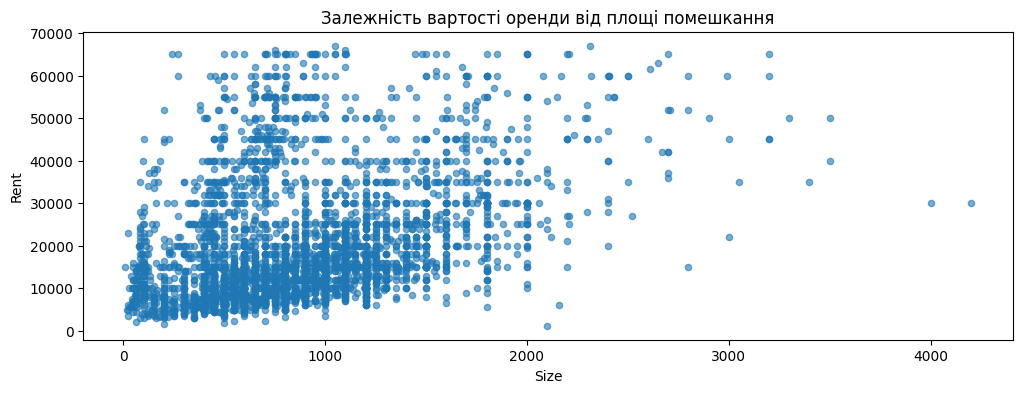

In [56]:
df_clean2.plot.scatter(
    x='Size',
    y='Rent',
    title='Залежність вартості оренди від площі помешкання',
    figsize=(12, 4),
    alpha=0.6
);

Присутній досить чіткий лінійний звʼязок між вартістю оренди житла та площею помешкання. При збільшенні площі частіше за все вартість оренди також буде збільшуватися. Проглядаються також фіксовані ціни на рівнях 20000, 30000, 40000 і т.д. незалежно від площі помешкання. Причину наразі встановити складно.

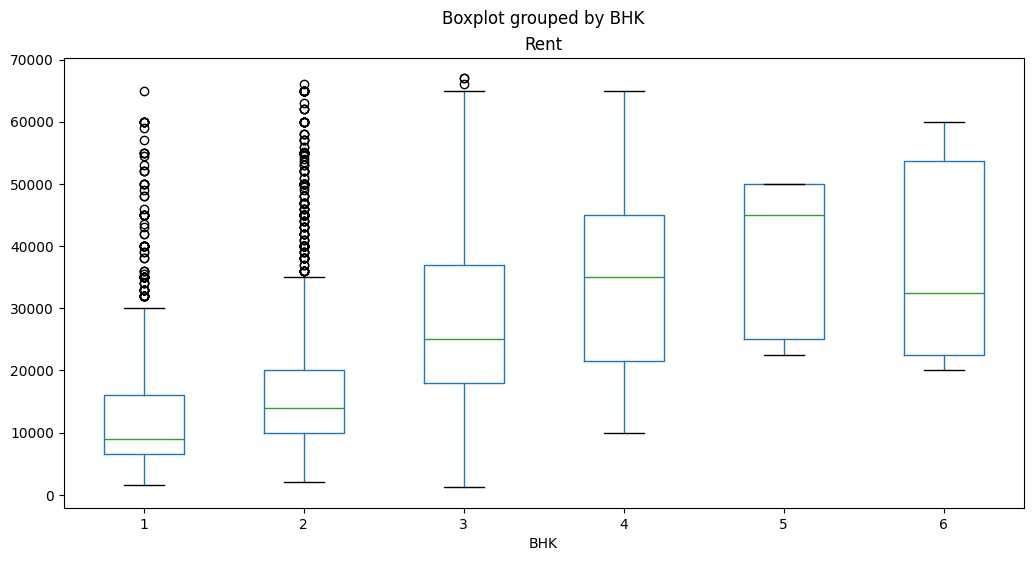

In [57]:
df_clean2.boxplot(
    column='Rent',
    by='BHK',
    figsize=(12, 6),
    grid = False
);

Для різних значень ВНК (від 1 до 6) простежуємо постійше збільшення середнього значення оренди з ВНК=1 до 5, і зменшення для ВНК=6. Найбільш скупчені результати між квартилями Q1 та Q3 демонструють ВНК=1 та 2, надалі значення більш розсіяні. Однак, для цих самих ВНК=1 та 2 присутня набагато більша кількість аутлаєрів. Найбільш компактний розподіл демонструє ВНК=5. Найдовші "вуса" у ВНК=3.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [93]:
city_dummies = pd.get_dummies(df_clean2['City'], prefix='City')

In [94]:
furni_dummies = pd.get_dummies(df_clean2['Furnishing Status'], prefix='Furn.Stat.')

In [95]:
city_dummies.head().astype(int)
furni_dummies.head().astype(int)

,Furn.Stat._Furnished,Furn.Stat._Semi-Furnished,Furn.Stat._Unfurnished
0,0,0,1
1,0,1,0
2,0,1,0
3,0,0,1
4,0,0,1


In [96]:
df_clean2 = pd.concat([df_clean2, city_dummies, furni_dummies], axis=1)

In [97]:
df_clean2.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'City_Bangalore', 'City_Chennai',
       'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai',
       'Furn.Stat._Furnished', 'Furn.Stat._Semi-Furnished',
       'Furn.Stat._Unfurnished'],
      dtype='object')

Додаткові ознаки (поверховість)

In [98]:
def parse_floor(x):

    if pd.isna(x):
        return pd.Series([np.nan, np.nan])

    x = str(x).strip()

    floor_map = {
        'Ground': 0,
        'Upper Basement': -1,
        'Lower Basement': -2
    }

    # випадок "1", "2", "3"
    if 'out of' not in x:

        if x in floor_map:
            return pd.Series([floor_map[x], np.nan])

        return pd.Series([int(x), np.nan])

    # випадок "3 out of 10"
    current, total = x.split(' out of ')

    total = int(total)

    if current in floor_map:
        current = floor_map[current]
    else:
        current = int(current)

    return pd.Series([current, total])

df_clean2[['current_floor', 'total_floors']] = (
    df_clean2['Floor'].apply(parse_floor)
)

In [99]:
#створення показника для відносного поверху
df_clean2['floor_ratio'] = (
    df_clean2['current_floor'] /
    df_clean2['total_floors']
)

In [100]:
#для ознаки підвалів
df_clean2['is_basement'] = (df_clean2['current_floor'] < 0).astype(int)

In [101]:
wrong_floors = df_clean2[
    (df_clean2['current_floor'] > df_clean2['total_floors']) &
    (df_clean2['total_floors'].notna())
]

print(wrong_floors[['Floor',
                    'current_floor',
                    'total_floors']])

          Floor  current_floor  total_floors
105  8 out of 5            8.0           5.0
161  2 out of 1            2.0           1.0


In [102]:
#видалення некоректних поверхів
df_clean2 = df_clean2.drop(
    wrong_floors.index
)

Видаляю зайві колонки:

In [107]:
df_clean3 = df_clean2.drop(
    columns=['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
)

In [108]:
df_clean3.columns

Index(['BHK', 'Rent', 'Size', 'Bathroom', 'City_Bangalore', 'City_Chennai',
       'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai',
       'Furn.Stat._Furnished', 'Furn.Stat._Semi-Furnished',
       'Furn.Stat._Unfurnished', 'current_floor', 'total_floors',
       'floor_ratio', 'is_basement'],
      dtype='object')

In [124]:
#видалення некоректного коефіцієнту поверховості
df_clean3 = df_clean3.dropna()

Визначаємо X та Y

In [125]:
X = df_clean3.drop(columns=['Rent'])
y = df_clean3['Rent']

print(f"\nРозмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")


Розмір X (ознак): (4220, 16)
Розмір y (цілі): (4220,)


Стандартизація числових ознак

In [126]:
from sklearn.preprocessing import StandardScaler

In [127]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [128]:
from sklearn.model_selection import train_test_split

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,
    random_state=44
)

In [131]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Вагові коефіцієнти

In [132]:
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: 2498.20
Size: 3878.11
Bathroom: 2248.90
City_Bangalore: -843.80
City_Chennai: -1536.96
City_Delhi: 965.15
City_Hyderabad: -2283.50
City_Kolkata: -1574.97
City_Mumbai: 5881.53
Furn.Stat._Furnished: 1005.11
Furn.Stat._Semi-Furnished: -51.09
Furn.Stat._Unfurnished: -619.33
current_floor: -263.05
total_floors: 2824.26
floor_ratio: 152.27
is_basement: 93.46

Зміщення (intercept): 19318.16


In [ ]:
Найбільша вага у ознаки Size та міста Mumbai, обидві позитивно впливають на Rent.

Прогнози

In [133]:
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Реальна вартість оренди': y_test.values[:10],
    'Прогнозована вартість': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})
print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна вартість оренди  Прогнозована вартість  Помилка
0                     9000                12894.0  -3894.0
1                    45000                45365.0   -365.0
2                    14000                 8052.0   5948.0
3                     6000                 3786.0   2214.0
4                     7500                15271.0  -7771.0
5                    16000                18238.0  -2238.0
6                    14000                14469.0   -469.0
7                     8500                14937.0  -6437.0
8                    24000                19490.0   4510.0
9                    30000                32070.0  -2070.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [135]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f} грош.од.")
print(f"RMSE: {rmse:.2f} грош.од.")
print(f"R²: {r2:.3f}")

mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f} грош.од.")
print(f"RMSE: {rmse:.2f} грош.од.")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 6142.83 грош.од.
RMSE: 8347.90 грош.од.
R²: 0.658
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 5751.78 грош.од.
RMSE: 8067.06 грош.од.
R²: 0.654


In [139]:
np.mean(y_train)

np.float64(19220.09952606635)

Значення середньої помилки та корню квардату помилки подібні на тестовій та тренувальній вибірках. Покизники також суттєво менші за Intersept та середнє по Rent. Коефіцієнт детермінації на рівні 0,65 в обох варіантах (тест та тренування), що означає, що обрані нами ознаки на 65% пояснюють вартість оренди.

Модель не показує ознаки перенавчання або недостатнього навчання: величина помилок та коеф.детермінації на тренувальній та тестовій вибірках суттєво не відрізняються.

In [140]:
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальна vs Прогнозована вартість оренди (тестова вибірка)',
    labels={'x': 'Реальна вартість', 'y': 'Прогнозована вартість'},
    opacity=0.6
)

max_val = max(y_test.max(), y_test_pred.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

Судячи із графіку розсіювання, наша модель працює непогано на обʼєктах, вартістю до 30000 грош.од., далі напевно є ознаки, які модель не опрацбовує, тому йде очевидне відхилення ідеального прогнозу від реальної вартості. Прогнозні значення починають перевищувати реальні більше, ніж до цього порогу. В цілому, модель непогана.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [141]:
residuals = y_test - y_test_pred

fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

In [143]:
# Scatter plot: помилки vs прогнозовані значення
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={'x': 'Прогнозована вартість', 'y': 'Помилка'},
    opacity=0.5
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

Із зростанням прогнозованого значення зростає помилка, найбільш очевидно це стає вже з 20000 грош.од (на цьому графіку це видно краще, ніж на реальній/прогнозній вартості). Однак, і густина значень після 20000 менша, ніж в проміжку до цього.

In [147]:
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
})

top_errors = errors_df.nlargest(5, 'error')
print("Пости з найбільшими помилками прогнозування:")
print(top_errors)

Пости з найбільшими помилками прогнозування:
       real     predicted         error
3520  65000  30941.008853  34058.991147
3962  65000  31942.756270  33057.243730
4408  55000  22406.510955  32593.489045
2045  60000  29172.629944  30827.370056
711    6500  35928.016391  29428.016391


In [152]:
results = X_test.copy()

results['actual_rent'] = y_test
results['predicted_rent'] = y_test_pred

results['abs_error'] = abs(
    results['actual_rent'] -
    results['predicted_rent']
)

results.groupby('BHK')['abs_error'].mean()

,abs_error
BHK,
-1.287464,4923.500887
0.053049,5634.046155
1.393562,8590.745929
2.734075,11116.470529
4.074587,577.353791
5.415100,23323.080090


Найбільша помилка в останньому рядку (це ВНК=6). Це могло статися через обмежену кількість даних в тестовій вибірці за ВНК=6.

In [154]:
results.groupby('BHK').size()

,0
BHK,
-1.287464,239
0.053049,414
1.393562,178
2.734075,11
4.074587,1
5.415100,1


Для покращення моделі я б ще прибрала нерепрезентаційні дані, тобто яких не вистачає для повноцінного аналізу (одиничні екземпляри, як наприклад з ВНК=5 та 6). А з виключених з моделі даних можливо в нагоді була б колонка із Tenant Preferred, і Posted On (з виділеним місяцем та роком, можливо є тенденція на зростання цін рік від року або їх падіння за сезонами).